# Linear Regression Modeling

The following are models based upon the imputed_house_sales.csv for ADS-500B Final Assignment

In [13]:
## Import Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
## Import CSV into Dataframe and run important methods to gain value
df = pd.read_csv('imputed_house_sales.csv')
df.info()
df['grade'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  float64
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  float64
 6   sqft_lot       21613 non-null  float64
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

array([ 7,  6,  8, 11,  9,  5, 10, 12,  4,  3, 13,  1])

In [15]:
## Select Dataframe columns based on type number to include for correlation and run correlations
df = df.select_dtypes(include=['number'])
correl = df.corr(method='spearman')

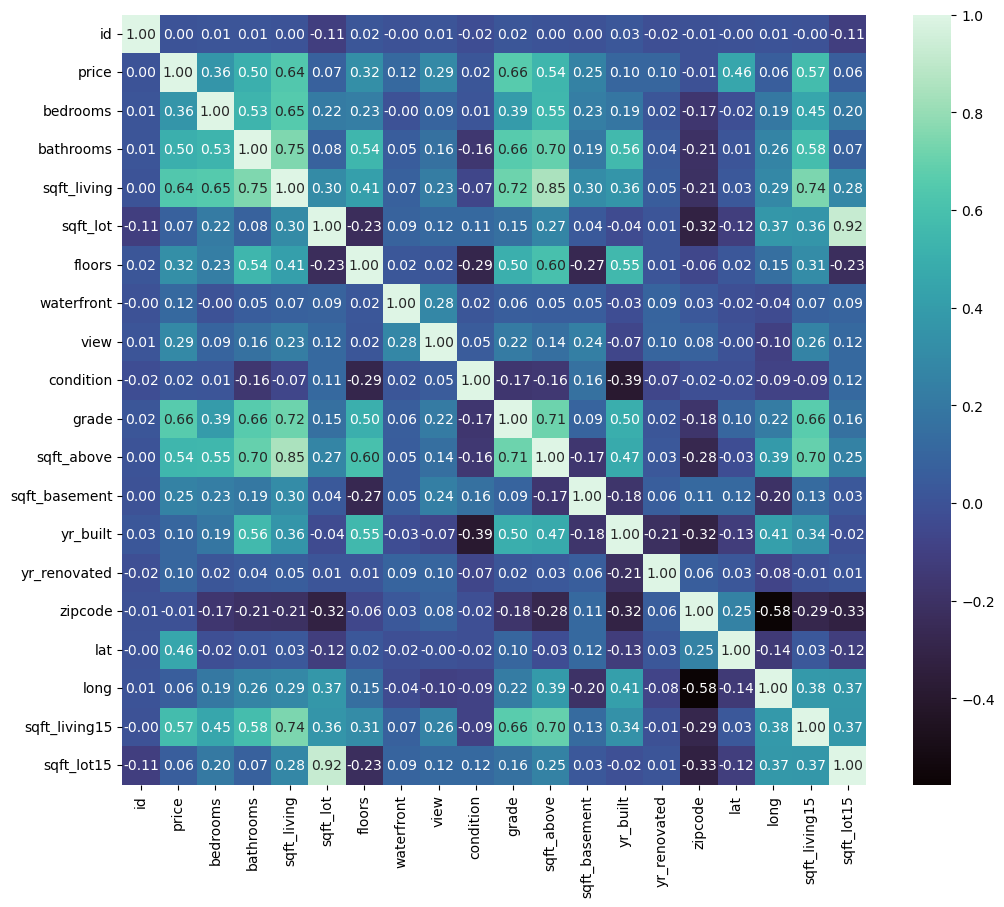

In [16]:
## Plot Correlation Heatmap for understaning of highly correlated features
plt.figure(figsize=(12, 10))
corrmap = sns.heatmap(correl, annot=True, cmap='mako', xticklabels=True, yticklabels=True, fmt = '.2F')

In [17]:
## Create correlations based upon absolute values and print
price_target_correlations = correl['price'].abs().sort_values(ascending=False)
print(price_target_correlations)

price            1.000000
grade            0.658215
sqft_living      0.639142
sqft_living15    0.572290
sqft_above       0.541752
bathrooms        0.503042
lat              0.456409
bedrooms         0.356137
floors           0.322347
view             0.293931
sqft_basement    0.251704
waterfront       0.115089
yr_built         0.102038
yr_renovated     0.101876
sqft_lot         0.073696
long             0.063537
sqft_lot15       0.062766
condition        0.018490
zipcode          0.008735
id               0.004178
Name: price, dtype: float64


In [49]:
# Create X and y for modeling, turn X into a dataframe
X1 = df['grade']
X2 = df[['grade', 'sqft_living', 'sqft_living15', 'sqft_above', 'bathrooms']]
X = pd.DataFrame(X2)
y = df['price']

A smaller feature set correlation of 'Grade vs Price' (X1, y) was originally run as a model, but the R2 Value (0.48) was below the current 5 Feature model (0.54), so we concluded that the higher R2 Feature set would be viable for a Linear Regression and used from here-on.

In [58]:
#Create OLS summary for statistical understanding
X2 = sm.add_constant(X)
X2_results = sm.OLS(y,X2).fit()
X2_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     5092.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:58:40   Log-Likelihood:            -2.9919e+05
No. Observations:               21613   AIC:                         5.984e+05
Df Residuals:                   21607   BIC:                         5.984e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -6.57e+05   1.35e+04    -48.540      0.000   -6.84e+05    -6.3e+05
grade          1.114e+05   2467.388     45.143      0.000    1.07e+05    1.16e+05
sqft_living     243.5763      4.648     52.408      0.000     234.467     252.686
sqft_living15    26.1309      4.032      6.481      0.000      18.227      34.034
sqft_above      -83.6387      4.546    -18.399      0.000     -92.549     -74.729
bathrooms      -3.07e+04   3507.500     -8.751      0.000   -3.76e+04   -2.38e+04
==============================================================================
Omnibus:                    17432.577   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1186231.118
Skew:                           3.400   Prob(JB):                         0.00
Kurtosis:                      38.651   Cond. No.                     2.94e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.94e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [59]:
# Create Train, test, split for Linear Regression Model
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=1)

In [60]:
# Create Linear Model and fit
lm = LinearRegression()
lin_model = lm.fit(X_train, y_train)
lin_model

LinearRegression()

In [61]:
# Predict Linear Model on X_test
pred = lin_model.predict(X_test)
pred

array([ 776305.85208732,  385361.97860004, 1002291.68588465, ...,
        586639.11253091, 1368498.44845709,  360582.74811905])

In [62]:
# Lower and Upper bound for Range of Fit
lower_bound = 0
upper_bound = y.quantile(0.99)

Text(0.5, 1.0, 'Predicted Housing Prices - Top Five Features')

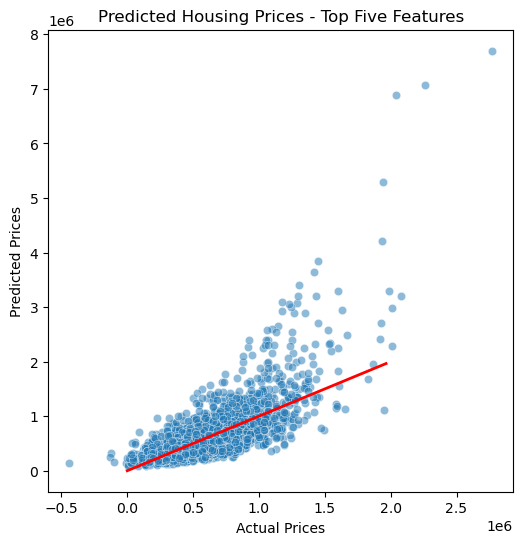

In [63]:
# Plot scatterplot and best fit line based upon bounds for Linear Regression for prediction
plt.figure(figsize=(6, 6))
sns.scatterplot(x=pred, y=y_test, alpha=0.5)
quantile_range = np.linspace(lower_bound, upper_bound, 10)
plt.plot(quantile_range, quantile_range, color='red', linestyle='-', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted Housing Prices - Top Five Features')

The above chart shows the best fit line for predicting what prices of houses could be based upon the set of actual features modeled.

# Clustering Model

In [26]:
# import new Kmeans library
from sklearn.cluster import KMeans

In [27]:
# Create 3 cluster centroids with random state, creating a dataframe 
kmeans1 = KMeans(n_clusters=3, 
                 random_state=1).fit(X)
centroids1 = pd.DataFrame(kmeans1.cluster_centers_,
columns = X.columns)
pd.set_option('display.precision', 3)
centroids1

,grade,sqft_living,sqft_living15,sqft_above,bathrooms
0,6.985,1450.047,1550.188,1232.022,1.683
1,9.548,3793.781,3155.873,3399.132,3.095
2,8.014,2436.994,2239.012,2068.334,2.424


In [28]:
# Create the WCSS (Within Cluster Sum of Squares) and show cluster count with members
withinClusterSS = [0] * 3
clusterCount = [0] * 3
for cluster, distance in zip(kmeans1.labels_,
                             kmeans1.transform(X)):
    withinClusterSS[cluster] += distance[cluster]**2
    clusterCount[cluster] += 1
for cluster, withClustSS in enumerate(withinClusterSS):
    print('Cluster {} ({} members): {:5.2f} within cluster'.format(cluster,
clusterCount[cluster], withinClusterSS[cluster]))

Cluster 0 (11416 members): 3709244690.34 within cluster
Cluster 1 (2642 members): 4562113448.60 within cluster
Cluster 2 (7555 members): 4147949631.01 within cluster


[42911874431.58681, 18537583013.264656, 12418818812.95119, 9747334162.558533, 8328690558.140539, 7499184532.935869]


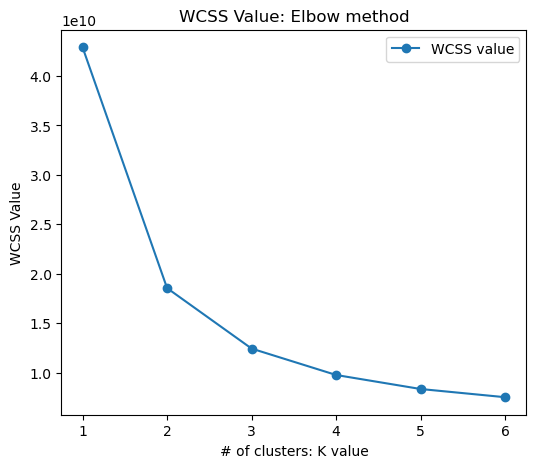

In [29]:
# Create elbow chart for Cluster precision
wcss=[]
for i in range(1,7):
    kmeans= KMeans(n_clusters = i, 
                   init = 'k-means++', 
                   random_state = 222)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
print(wcss)

fig, ax = plt.subplots(figsize=(6,5))
plt.plot(range(1,7), 
         wcss, linestyle='-', 
         marker='o', 
         label='WCSS value')
plt.title('WCSS Value: Elbow method')
plt.xlabel('# of clusters: K value')
plt.ylabel('WCSS Value')
plt.legend()
plt.show()

The above chart shows that three clusters is an appropriate value of clusters to use for a K-Means Clustering Model

In [30]:
# Scale values of X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
# Fit K-Means model with scaled features
kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto')
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=1)

In [32]:
# Obtain Cluster labels and Centroids
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

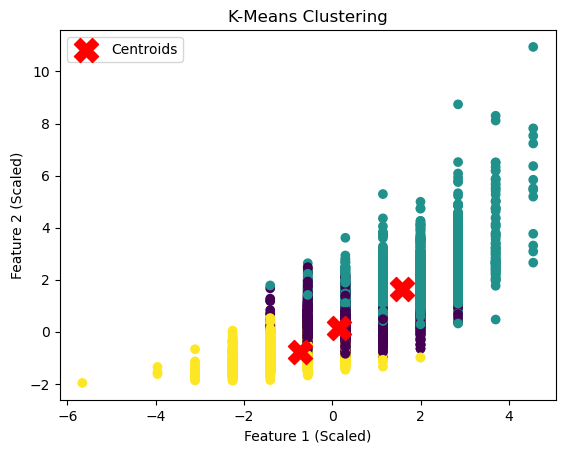

In [33]:
# Plot K-Means Model
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.show()

### The Following is K-Means Model (Unsupervised) without Feature Scaling

In [34]:
# Fit K-Means with 3 Clusters (non scaled)
X3 = df['price'].to_frame()
kmeans = KMeans(n_clusters=3, random_state=2, n_init='auto')
kmeans.fit_predict(X3)

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [35]:
# Obtain Cluster labels and Centroids
cluster_labels2 = kmeans.labels_
centroids2 = kmeans.cluster_centers_

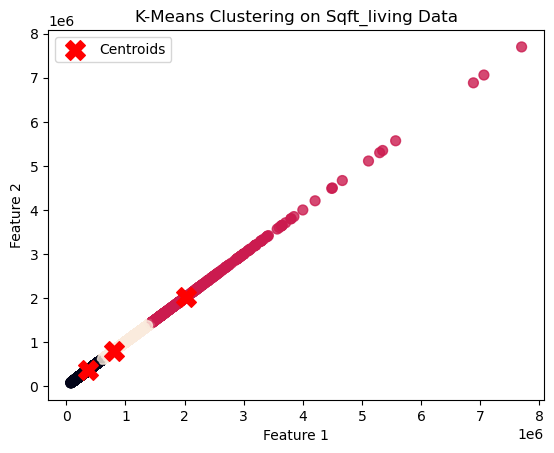

In [36]:
# Plot K-Means
plt.scatter(X3.iloc[:, 0], X3.iloc[:, 0], c=cluster_labels2, cmap='rocket', s=50, alpha=0.8)
plt.scatter(centroids2[:, 0], centroids2[:, 0], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering on Sqft_living Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

### K-Nearest Neighbors Models (Supervised) for Classification

In [71]:
# Load a dataset
X4 = df[['yr_built']]
y4 = df['yr_renovated']

In [72]:
# Train the dataset
X_train, X_test, y_train, y_test = train_test_split(X4, y4, test_size=0.3, random_state=1)

In [73]:
# Create Number of neightbors and fit model to the training data
knn = KNeighborsClassifier(n_neighbors=3) 
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [74]:
# Predict neighbors and evaluate
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


The above K-NN Model between Year Built and Year Renovated has an extremely high accuracy rating of 0.96. This score states that there is a high correlation between the year built and the year renovated. More research would be necessary to validate whether this is causation or mainly correlation.